# Preparacion de datos para los algoritmos de ML

In [28]:
import pandas as pd

In [29]:
datos_crudos = pd.read_csv('../data/raw/housing/housing.csv')

In [30]:
# Calidad de datos
# Precision
# 1. Outliers
# 2. Inconsistencia en escalas
# 3. Valores repetidos / duplicados
# 4. Inconsistencias en los datos (tipo de dato, signo)
# Completitud
# 1. Ausentes




In [31]:
# Completitud: Manejo de valores ausentes

datos_crudos.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [32]:
datos_crudos[datos_crudos['total_bedrooms'].isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
182,-118.27,34.04,13.0,1784.0,NaN,2158.0,682.0,1.7038,118100.0,<1H OCEAN
327,-117.65,34.04,15.0,3393.0,NaN,2039.0,611.0,3.9336,151000.0,INLAND
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,271800.0,NEAR OCEAN
477,-117.99,34.14,30.0,2346.0,NaN,1988.0,474.0,2.5625,153000.0,INLAND
495,-114.59,34.83,41.0,812.0,NaN,375.0,158.0,1.7083,48500.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
19880,-118.23,33.94,36.0,1110.0,NaN,1417.0,302.0,2.3333,92100.0,<1H OCEAN
19952,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20088,-119.73,36.83,8.0,3602.0,NaN,1959.0,580.0,5.3478,138800.0,INLAND
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN


In [33]:
# Hacer un EDA de los datos ausentes

In [34]:
# 1. Borrar las filas
# 2. Borrar la columna
# 3. Imputar

In [35]:
metricas_datos_ausentes = datos_crudos.isna().sum().reset_index()

In [36]:
metricas_datos_ausentes.columns = ['nombre_columna', 'total_ausentes']

In [37]:
metricas_datos_ausentes['%_total'] = metricas_datos_ausentes['total_ausentes'] / datos_crudos.shape[0]

In [38]:
datos_crudos.shape

(20640, 10)

In [39]:
metricas_datos_ausentes

,nombre_columna,total_ausentes,%_total
0,longitude,0,0.000000
1,latitude,0,0.000000
2,housing_median_age,0,0.000000
3,total_rooms,0,0.000000
4,total_bedrooms,207,0.010029
5,population,0,0.000000
6,households,0,0.000000
7,median_income,0,0.000000
8,median_house_value,0,0.000000
9,ocean_proximity,0,0.000000


In [40]:
datos_limpios = datos_crudos.copy()

In [41]:
datos_limpios.dropna(subset=['total_bedrooms'], inplace=True) # Opcion: borrar filas ausentes

In [42]:
datos_limpios.drop('total_bedrooms', axis=1) # Opcion: borrar columna

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,741.0,349.0,1.8672,84700.0,INLAND


In [43]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [44]:
datos_limpios.reset_index(inplace=True, drop=True)

In [45]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [46]:
datos_limpios_imputados = datos_crudos.copy()

# Tipos de clase en SKLEARN
## Estimador -> fit()
## Transformador -> transform() transforma los datos
## Predictor -> predict()

In [47]:
from sklearn.impute import SimpleImputer
import numpy as np

# Mediana, Media -> No pueden ser usados en varias de texto!!!

imputador = SimpleImputer(strategy='median')

# Seleccionar Filas numericas

data_pre_imputacion = datos_limpios_imputados.select_dtypes(include=[np.number])

imputador.fit(data_pre_imputacion)

# .fit_transform()

SimpleImputer(strategy='median')

In [48]:
datos_limpios_imputados = imputador.transform(data_pre_imputacion)

In [49]:
imputador.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'], dtype=object)

In [50]:
type(datos_limpios_imputados)

numpy.ndarray

In [51]:
datos_limpios_imputados = pd.DataFrame(datos_limpios_imputados, 
                            columns=data_pre_imputacion.columns,
                            index=data_pre_imputacion.index)

In [52]:
datos_limpios_imputados.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [53]:
imputador.strategy

'median'

In [54]:
# Outliers

In [55]:
# Filtrar los outliers por 3*std o > Q3 + 1.5*IQR O < Q1 - 1.5IQR

# Identificar los atipicos con un predictor 'inteligente'

In [56]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=123)

datos_limpios_numericos = datos_limpios.select_dtypes(include=[np.number])

prediccion_atipicos = isolation_forest.fit_predict(datos_limpios_numericos)


In [57]:
prediccion_atipicos

array([-1, -1, -1, ...,  1,  1,  1])

In [58]:
#datos_limpios = datos_limpios.iloc[prediccion_atipicos == 1]

In [59]:
#datos_limpios.info()

In [60]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [61]:
# Manejo de variables de texto -> Categoricas

In [62]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [63]:
datos_cat = datos_limpios[['ocean_proximity']]

In [64]:
type(datos_cat)

pandas.core.frame.DataFrame

In [65]:
datos_cat.value_counts()

ocean_proximity
<1H OCEAN          9034
INLAND             6496
NEAR OCEAN         2628
NEAR BAY           2270
ISLAND                5
Name: count, dtype: int64

In [66]:
# Encoding -> Texto a Numeros
# Nominal: sin orden
# Ordinal: con orden

In [67]:
from sklearn.preprocessing import OrdinalEncoder

codificador_ordinal = OrdinalEncoder()

datos_cat_cod = codificador_ordinal.fit_transform(datos_cat)

In [68]:
datos_cat_cod

array([[3.],
       [3.],
       [3.],
       ...,
       [1.],
       [1.],
       [1.]])

In [69]:
codificador_ordinal.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [70]:
datos_limpios

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20428,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20429,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20430,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20431,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [71]:
datos_limpios_nominal = pd.get_dummies(datos_limpios, drop_first=True)

In [72]:
datos_limpios['ocean_proximity_ordinal'] = datos_cat_cod

In [73]:
datos_limpios['ocean_proximity_ordinal'] = datos_limpios['ocean_proximity_ordinal'].astype(int)

In [74]:
# Feature Scaling:
# Normalizacion -> rango fijo = [-1,1]
# Estandarizacion -> normal: media=0 y std=1

In [75]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [76]:
min_max = MinMaxScaler(feature_range=(-1,1))
standard = StandardScaler()

In [77]:
datos_limpios.drop(columns=['ocean_proximity'], inplace=True)

In [78]:
norm_scaling_features = min_max.fit_transform(datos_limpios)
stand_scaling_features = standard.fit_transform(datos_limpios)

# TODO: Transformar a DataFrames y Comparar distirbuciones de cada escalamiento con los datos originales

df_minmax = pd.DataFrame(norm_scaling_features, columns=datos_limpios.columns, index=datos_limpios.index)
df_standard = pd.DataFrame(stand_scaling_features, columns=datos_limpios.columns, index=datos_limpios.index)

# Comparar estadísticos entre original y escalados
stats_orig = datos_limpios.describe()
stats_minmax = df_minmax.describe()
stats_standard = df_standard.describe()

comparacion = pd.concat([
    stats_orig.add_suffix('_orig'),
    stats_minmax.add_suffix('_minmax'),
    stats_standard.add_suffix('_standard')
], axis=1)

comparacion.loc[['mean','std','min','25%','50%','75%','max']]

comparacion.head()


,longitude_orig,latitude_orig,housing_median_age_orig,total_rooms_orig,total_bedrooms_orig,population_orig,households_orig,median_income_orig,median_house_value_orig,ocean_proximity_ordinal_orig,...,longitude_standard,latitude_standard,housing_median_age_standard,total_rooms_standard,total_bedrooms_standard,population_standard,households_standard,median_income_standard,median_house_value_standard,ocean_proximity_ordinal_standard
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,...,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04,2.043300e+04
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,1.166153,...,-8.777027e-16,1.495294e-15,3.477427e-17,-3.833864e-17,-7.424307e-17,-8.345826e-17,-6.415854e-17,-1.620481e-16,9.910668e-17,-1.599617e-17
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,1.420135,...,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000,...,-2.385447e+00,-1.447937e+00,-2.194584e+00,-1.205604e+00,-1.274093e+00,-1.254828e+00,-1.303810e+00,-1.775054e+00,-1.662139e+00,-8.211765e-01
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000,...,-1.112692e+00,-7.972780e-01,-8.444662e-01,-5.429688e-01,-5.740034e-01,-5.629702e-01,-5.739976e-01,-6.884113e-01,-7.568419e-01,-8.211765e-01


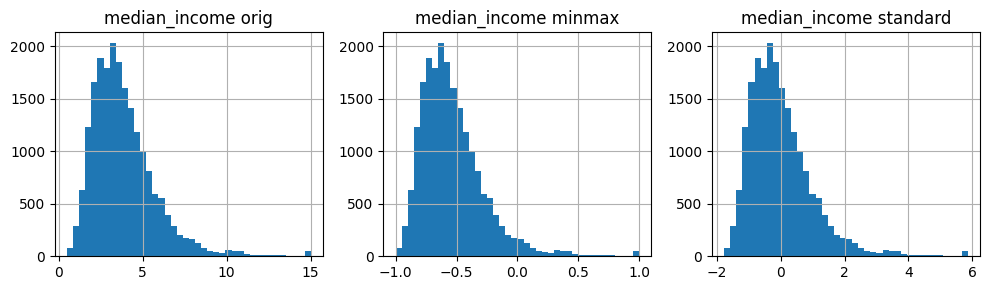

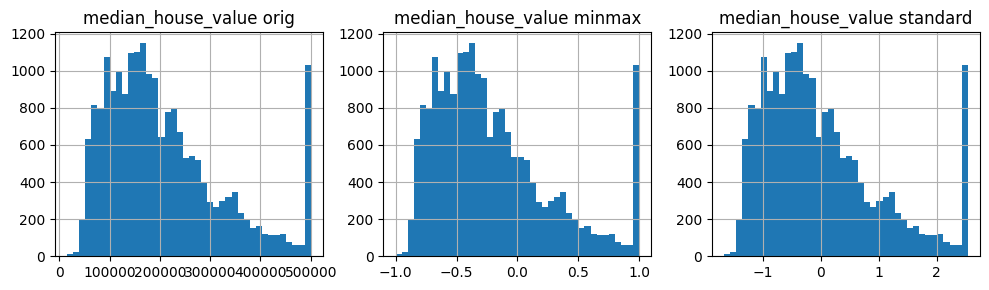

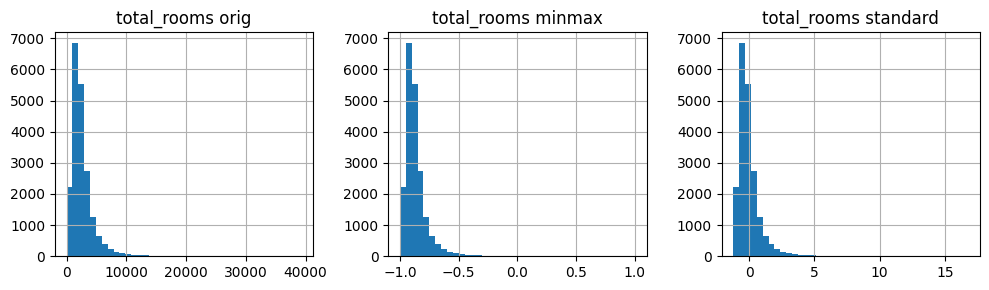

In [79]:
# Ver visualmente la comparaicon de distribución
import matplotlib.pyplot as plt

cols = ['median_income', 'median_house_value', 'total_rooms']
for c in cols:
    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); datos_limpios[c].hist(bins=40); plt.title(f'{c} orig')
    plt.subplot(1,3,2); df_minmax[c].hist(bins=40); plt.title(f'{c} minmax')
    plt.subplot(1,3,3); df_standard[c].hist(bins=40); plt.title(f'{c} standard')
    plt.tight_layout()
    plt.show()


In [80]:
# TODO: Hacer una tuberia para el dataset de entrenamiento separar datasets para validar, entrenar y probar. Objetivo es predecir el precio

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# eliminar columna categórica
datos_numericos = datos_crudos.drop(columns=['ocean_proximity'])

# separar características y objetivo
caracteristicas = datos_numericos.drop(columns=['median_house_value'])
objetivo = datos_numericos['median_house_value']

# pipeline de preprocesamiento
pipeline_preprocesamiento = Pipeline([
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler())
])

caracteristicas_procesadas = pipeline_preprocesamiento.fit_transform(caracteristicas)

# separar entrenamiento + validación y prueba
caract_entren_valid, caract_prueba, obj_entren_valid, obj_prueba = train_test_split(
    caracteristicas_procesadas, objetivo, test_size=0.2, random_state=123
)

# separar entrenamiento y validación
caract_entrenamiento, caract_validacion, obj_entrenamiento, obj_validacion = train_test_split(
    caract_entren_valid, obj_entren_valid, test_size=0.2, random_state=123
)

print(f'Validacion Completitud', pd.DataFrame(caract_validacion).isna().sum())


Validacion Completitud 0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64


In [81]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Con Pipeline se debe usar lista de tuplas, no set
tuberia_transformacion = Pipeline([
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler())
])


In [83]:
datos_transformados = tuberia_transformacion.fit_transform(datos_limpios)

# fit_transform devuelve numpy array. Convertir a DataFrame para usar to_csv
datos_transformados_df = pd.DataFrame(datos_transformados, columns=datos_limpios.columns, index=datos_limpios.index)
datos_transformados_df.to_csv('../data/processed/datos_transformados.csv', index=False)

In [85]:
datos_crudos.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [86]:
datos_crudos.duplicated().sum()

0

In [87]:
datos_crudos_sin_ausentes = datos_crudos.dropna()

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer    
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipelines = Pipeline([
    ('imputacion', SimpleImputer(strategy='median')),
    ('escalado', StandardScaler()),
])

cat_pipelines = Pipeline([
    ('imputacion', SimpleImputer(strategy='most_frequent')),
    ('codificacion', OneHotEncoder(handle_unknown='ignore')),
])

In [92]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ('num', num_pipelines, datos_crudos.select_dtypes(include=[np.number]).columns),
    ('cat', cat_pipelines, datos_crudos.select_dtypes(include=['object']).columns)  
])

datos_transformados = preprocessing.fit_transform(datos_crudos)

# El obejtivo es dejar esto de forma profesional. lo anterior es un borrador de lo que se puede hacer. Hay que dejarlo como un script o notebook limpio, con comentarios y explicaciones claras.

# fit_transform devuelve numpy array. Convertir a DataFrame para usar to_csv
datos_transformados_df = pd.DataFrame(datos_transformados, columns=preprocessing.get_feature_names_out())
datos_transformados_df.to_csv('../data/processed/datos_transformados.csv', index=False)